In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.14.0+cpu
Device: cpu


In [3]:
project_root = Path.cwd().parent

if not (project_root / "data").exists():
    project_root = Path.cwd().parent.parent

processed_dir = project_root / "data" / "processed"
checkpoint_dir = project_root / "models" / "checkpoints"

clean_metadata_path = (
    processed_dir / "agrisense_metadata_clean.csv"
)

print("Project root:", project_root)
print("Metadata exists:", clean_metadata_path.exists())
print("Checkpoint directory exists:", checkpoint_dir.exists())

Project root: c:\Users\Dell\Documents\Projects\AgriSense
Metadata exists: True
Checkpoint directory exists: True


In [4]:
df_clean = pd.read_csv(clean_metadata_path)

disease_classes = sorted(df_clean["Disease"].unique())

disease_to_id = {
    disease: idx
    for idx, disease in enumerate(disease_classes)
}

id_to_disease = {
    idx: disease
    for disease, idx in disease_to_id.items()
}

df_clean["disease_id"] = df_clean["Disease"].map(disease_to_id)

print("Dataset shape:", df_clean.shape)
print("Disease classes:", len(disease_classes))
print("Missing disease IDs:", df_clean["disease_id"].isna().sum())

Dataset shape: (7399, 12)
Disease classes: 115
Missing disease IDs: 0


In [5]:
image_root = (
    project_root
    / "data"
    / "raw"
    / "PlantSeg"
    / "images"
)

image_files = list(image_root.rglob("*"))

image_lookup = {
    path.name: path
    for path in image_files
    if path.is_file()
}

df_clean["actual_image_path"] = (
    df_clean["Name"].map(image_lookup)
)

print(
    "Missing image paths:",
    df_clean["actual_image_path"].isna().sum()
)

Missing image paths: 0


In [6]:
# Recreate and load the fine-tuned ResNet-18

num_classes = len(disease_classes)

# Recreate ResNet-18 architecture
weights = models.ResNet18_Weights.DEFAULT

classifier_model = models.resnet18(weights=weights)

# Replace ImageNet classification head
classifier_model.fc = nn.Linear(
    classifier_model.fc.in_features,
    num_classes
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

classifier_model = classifier_model.to(device)

print("Device:", device)
print("Number of classes:", num_classes)

Device: cpu
Number of classes: 115


In [7]:
# Load the fine-tuned checkpoint

classifier_checkpoint_path = (
    checkpoint_dir
    / "resnet18_finetuned_best.pth"
)

print(
    "Checkpoint exists:",
    classifier_checkpoint_path.exists()
)

checkpoint = torch.load(
    classifier_checkpoint_path,
    map_location=device
)

classifier_model.load_state_dict(
    checkpoint["model_state_dict"]
)

classifier_model.eval()

print("Fine-tuned ResNet-18 loaded.")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])
print("Validation accuracy:", checkpoint["val_accuracy"])
print("Validation Macro F1:", checkpoint["val_macro_f1"])

Checkpoint exists: True
Fine-tuned ResNet-18 loaded.
Checkpoint epoch: 5
Validation loss: 1.5560793709078788
Validation accuracy: 0.5684340320591862
Validation Macro F1: 0.4176858941901695


In [8]:
# Define U-net Architecture

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Pooling
        self.pool = nn.MaxPool2d(2)

        # Decoder
        self.up3 = nn.ConvTranspose2d(
            256, 128,
            kernel_size=2,
            stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64,
            kernel_size=2,
            stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32,
            kernel_size=2,
            stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        # Output
        self.output = nn.Conv2d(
            32,
            1,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)

In [9]:
# Load the U-Net checkpoint

segmentation_model = UNet().to(device)

segmentation_checkpoint_path = (
    checkpoint_dir
    / "unet_segmentation_best.pth"
)

print(
    "Checkpoint exists:",
    segmentation_checkpoint_path.exists()
)

segmentation_checkpoint = torch.load(
    segmentation_checkpoint_path,
    map_location=device
)

segmentation_model.load_state_dict(
    segmentation_checkpoint["model_state_dict"]
)

segmentation_model.eval()

print("U-Net loaded.")
print(
    "Checkpoint epoch:",
    segmentation_checkpoint["epoch"]
)
print(
    "Validation loss:",
    segmentation_checkpoint["val_loss"]
)

Checkpoint exists: True
U-Net loaded.
Checkpoint epoch: 5
Validation loss: 0.9462818199513006


In [10]:
# Classification preprocessing

class ResizeWithPadding:
    def __init__(self, size):
        self.target_h, self.target_w = size

    def __call__(self, image):
        w, h = image.size

        scale = min(
            self.target_w / w,
            self.target_h / h
        )

        new_w = int(round(w * scale))
        new_h = int(round(h * scale))

        image = image.resize(
            (new_w, new_h),
            Image.Resampling.BILINEAR
        )

        canvas = Image.new(
            "RGB",
            (self.target_w, self.target_h),
            (0, 0, 0)
        )

        left = (self.target_w - new_w) // 2
        top = (self.target_h - new_h) // 2

        canvas.paste(image, (left, top))

        return canvas


classification_transform = transforms.Compose([
    ResizeWithPadding((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
# Segmentation preprocessing

def segmentation_preprocess(image):
    image = image.resize(
        (224, 224),
        Image.Resampling.BILINEAR
    )

    image = np.array(image).astype(np.float32) / 255.0

    image_tensor = torch.from_numpy(
        image
    ).permute(2, 0, 1)

    return image_tensor

In [12]:
# Test both preprocessing pipelines

test_sample = df_clean[
    df_clean["Split"] == "Test"
].iloc[0]

test_image = Image.open(
    test_sample["actual_image_path"]
).convert("RGB")

classifier_tensor = classification_transform(
    test_image
).unsqueeze(0).to(device)

segmentation_tensor = segmentation_preprocess(
    test_image
).unsqueeze(0).to(device)

print("Original image size:", test_image.size)
print("Classifier input:", classifier_tensor.shape)
print("Segmentation input:", segmentation_tensor.shape)

Original image size: (600, 350)
Classifier input: torch.Size([1, 3, 224, 224])
Segmentation input: torch.Size([1, 3, 224, 224])


In [13]:
# create the classifier prediction function

def predict_disease(image):
    classifier_model.eval()

    image_tensor = classification_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = classifier_model(image_tensor)
        probabilities = torch.softmax(logits, dim=1)

    confidence, predicted_id = torch.max(probabilities, dim=1)

    predicted_id = predicted_id.item()
    confidence = confidence.item()

    predicted_disease = id_to_disease[predicted_id]

    return predicted_disease, confidence, probabilities

In [14]:
predicted_disease, confidence, probabilities = predict_disease(test_image)

print("Predicted disease:", predicted_disease)
print("Confidence:", round(confidence, 4))

Predicted disease: zucchini yellow mosaic virus
Confidence: 0.2363


In [15]:
#segmentation prediction

def predict_segmentation(image):
    segmentation_model.eval()

    image_tensor = segmentation_preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = segmentation_model(image_tensor)
        probabilities = torch.sigmoid(logits)

    probability_map = probabilities[0, 0].cpu().numpy()

    return probability_map

In [16]:
segmentation_probability = predict_segmentation(test_image)

print("Segmentation map shape:", segmentation_probability.shape)
print("Minimum probability:", round(segmentation_probability.min(), 4))
print("Maximum probability:", round(segmentation_probability.max(), 4))

Segmentation map shape: (224, 224)
Minimum probability: 0.0091
Maximum probability: 0.9184


In [17]:
# create disease mask + coverage

SEGMENTATION_THRESHOLD = 0.4

predicted_mask = segmentation_probability >= SEGMENTATION_THRESHOLD

mask_coverage = predicted_mask.mean()

print("Segmentation threshold:", SEGMENTATION_THRESHOLD)
print("Predicted mask pixels:", predicted_mask.sum())
print("Predicted mask coverage:", round(mask_coverage, 4))
print("Predicted mask coverage (%):", round(mask_coverage * 100, 2))

Segmentation threshold: 0.4
Predicted mask pixels: 16292
Predicted mask coverage: 0.3247
Predicted mask coverage (%): 32.47


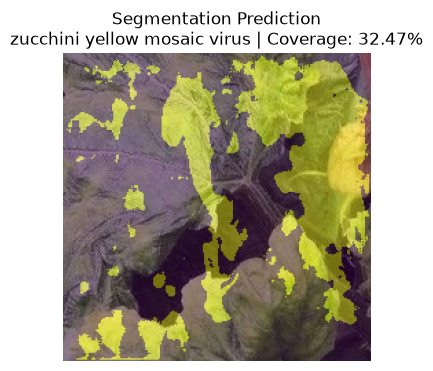

In [18]:
# visualize the segmentation

plt.figure(figsize=(4, 4))

plt.imshow(test_image)
plt.imshow(predicted_mask, alpha=0.45)

plt.title(
    f"Segmentation Prediction\n"
    f"{predicted_disease} | Coverage: {mask_coverage * 100:.2f}%"
)

plt.axis("off")
plt.show()

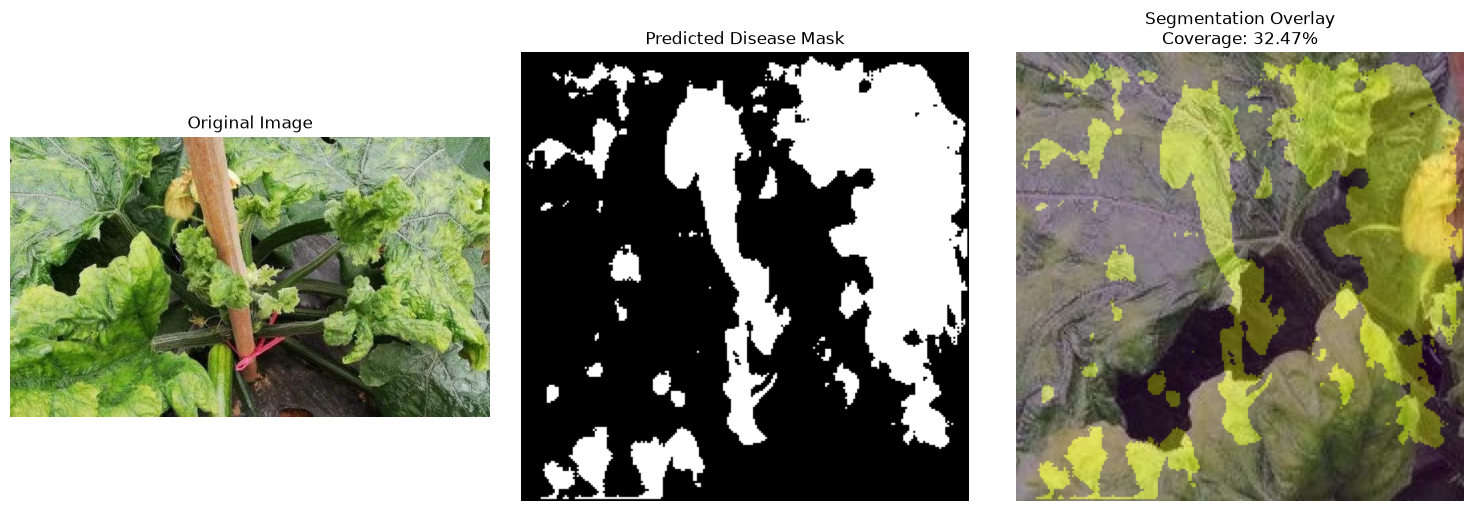

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(test_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Predicted binary mask
axes[1].imshow(predicted_mask, cmap="gray")
axes[1].set_title("Predicted Disease Mask")
axes[1].axis("off")

# Overlay
axes[2].imshow(test_image)
axes[2].imshow(predicted_mask, alpha=0.35)
axes[2].set_title(
    f"Segmentation Overlay\nCoverage: {mask_coverage * 100:.2f}%"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [20]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(
            self.save_activations
        )

        self.backward_handle = target_layer.register_full_backward_hook(
            self.save_gradients
        )

    def save_activations(self, module, input, output):
        self.activations = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image_tensor, class_index):
        self.model.zero_grad()

        output = self.model(image_tensor)

        target_score = output[:, class_index].sum()
        target_score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = F.interpolate(
            cam,
            size=image_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze()

        cam_min = cam.min()
        cam_max = cam.max()

        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.detach().cpu().numpy(), output.detach()

In [21]:
gradcam = GradCAM(
    classifier_model,
    classifier_model.layer4[-1]
)

print("Grad-CAM initialized.")

Grad-CAM initialized.


In [22]:
classifier_tensor = classification_transform(test_image).unsqueeze(0).to(device)

predicted_id = disease_to_id[predicted_disease]

gradcam_map, classifier_output = gradcam.generate(
    classifier_tensor,
    predicted_id
)

print("Grad-CAM shape:", gradcam_map.shape)
print("Predicted class:", predicted_disease)
print("Grad-CAM range:", round(gradcam_map.min(), 4), "to", round(gradcam_map.max(), 4))

Grad-CAM shape: (224, 224)
Predicted class: zucchini yellow mosaic virus
Grad-CAM range: 0.0 to 1.0


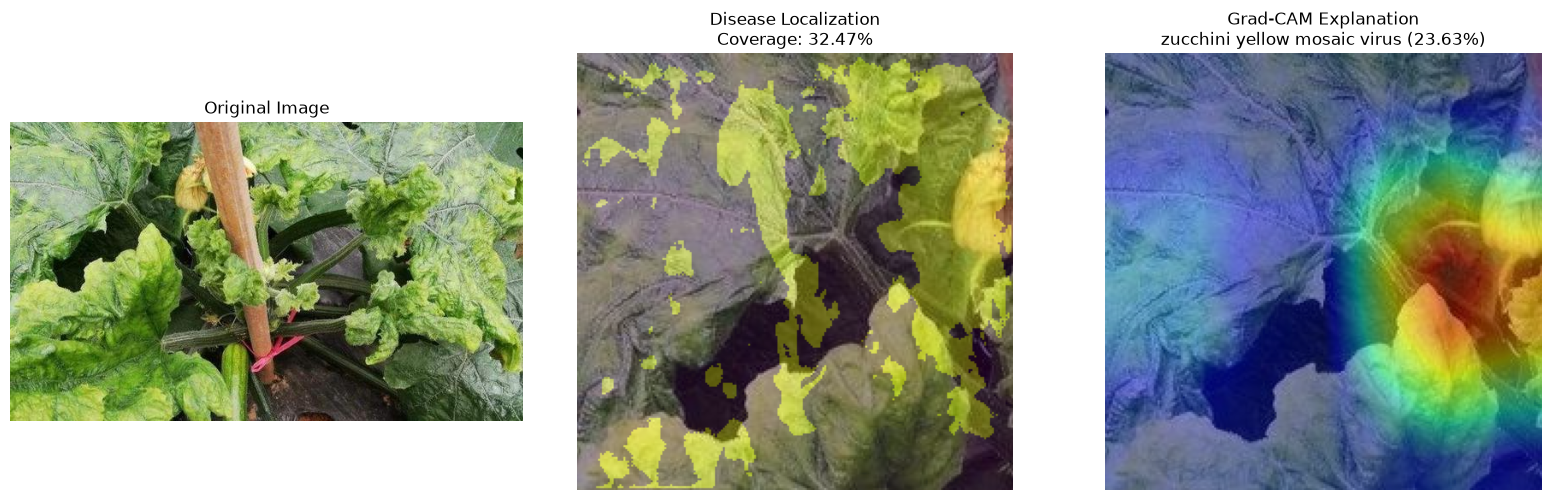

In [23]:
# Combined explanation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Original image
axes[0].imshow(test_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

# 2. U-Net segmentation
axes[1].imshow(test_image)
axes[1].imshow(predicted_mask, alpha=0.35)
axes[1].set_title(
    f"Disease Localization\n"
    f"Coverage: {mask_coverage * 100:.2f}%"
)
axes[1].axis("off")

# 3. Grad-CAM
axes[2].imshow(test_image)
axes[2].imshow(gradcam_map, cmap="jet", alpha=0.45)
axes[2].set_title(
    f"Grad-CAM Explanation\n"
    f"{predicted_disease} ({confidence * 100:.2f}%)"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [24]:
# Complete AgriSense prediction function

def run_agrisense_prediction(image):
    classifier_model.eval()
    segmentation_model.eval()

    # 1. Disease classification

    classifier_tensor = (
        classification_transform(image)
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():
        logits = classifier_model(classifier_tensor)
        probabilities = torch.softmax(logits, dim=1)

    confidence, predicted_id = torch.max(probabilities, dim=1)

    predicted_id = predicted_id.item()
    confidence = confidence.item()
    predicted_disease = id_to_disease[predicted_id]

    # 2. Disease segmentation

    segmentation_tensor = (
        segmentation_preprocess(image)
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():
        segmentation_logits = segmentation_model(segmentation_tensor)
        segmentation_probabilities = torch.sigmoid(segmentation_logits)

    probability_map = segmentation_probabilities[0, 0].cpu().numpy()

    # Validated threshold from Notebook 07
    predicted_mask = probability_map >= SEGMENTATION_THRESHOLD
    mask_coverage = predicted_mask.mean()

    # 3. Grad-CAM explanation

    gradcam_map, _ = gradcam.generate(
        classifier_tensor,
        predicted_id
    )

    return {
        "predicted_disease": predicted_disease,
        "confidence": confidence,
        "segmentation_probability": probability_map,
        "predicted_mask": predicted_mask,
        "mask_coverage": mask_coverage,
        "gradcam_map": gradcam_map
    }

In [25]:
# Testing the complete pipeline

result = run_agrisense_prediction(test_image)

print("AgriSense Prediction")
print("-" * 40)
print("Disease:", result["predicted_disease"])
print("Confidence:", f"{result['confidence'] * 100:.2f}%")
print("Mask coverage:", f"{result['mask_coverage'] * 100:.2f}%")
print("Grad-CAM shape:", result["gradcam_map"].shape)
print("Segmentation mask shape:", result["predicted_mask"].shape)

AgriSense Prediction
----------------------------------------
Disease: zucchini yellow mosaic virus
Confidence: 23.63%
Mask coverage: 32.47%
Grad-CAM shape: (224, 224)
Segmentation mask shape: (224, 224)


In [26]:
def visualize_agrisense_result(image, result):
    predicted_disease = result["predicted_disease"]
    confidence = result["confidence"]
    predicted_mask = result["predicted_mask"]
    mask_coverage = result["mask_coverage"]
    gradcam_map = result["gradcam_map"]

    # Basic measurements

    mask_percentage = mask_coverage * 100

    gradcam_mean = gradcam_map.mean()
    gradcam_high = (gradcam_map >= 0.5).mean() * 100

    # Display

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # 1. Original
    axes[0].imshow(image)
    axes[0].set_title("1. Original Image")
    axes[0].axis("off")

    # 2. U-Net mask
    axes[1].imshow(predicted_mask, cmap="gray")
    axes[1].set_title(
        f"2. Predicted Disease Mask\n"
        f"Coverage: {mask_percentage:.2f}%"
    )
    axes[1].axis("off")

    # 3. U-Net overlay
    axes[2].imshow(image)
    axes[2].imshow(predicted_mask, alpha=0.35)
    axes[2].set_title("3. Disease Localization")
    axes[2].axis("off")

    # 4. Grad-CAM
    axes[3].imshow(image)
    axes[3].imshow(gradcam_map, cmap="jet", alpha=0.45)
    axes[3].set_title(
        f"4. Grad-CAM\n"
        f"{predicted_disease}"
    )
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    # Interpretation

    print("\n" + "=" * 55)
    print("AgriSense Interpretation Guide")
    print("=" * 55)

    print(f"\nPredicted disease : {predicted_disease}")
    print(f"Confidence        : {confidence * 100:.2f}%")
    print(f"Predicted coverage: {mask_percentage:.2f}%")
    print(f"Grad-CAM mean     : {gradcam_mean:.3f}")
    print(f"Grad-CAM ≥ 0.5    : {gradcam_high:.2f}%")

    print("\nHow to read the four panels:")
    print("\n1. ORIGINAL IMAGE")
    print("   → Look at the actual plant, leaves and visible symptoms.")

    print("\n2. PREDICTED DISEASE MASK")
    print("   → White = U-Net predicts disease-region pixels.")
    print("   → Black = U-Net predicts background/non-disease.")

    print("\n3. DISEASE LOCALIZATION")
    print("   → Check whether the predicted mask falls on meaningful")
    print("     plant/leaf regions rather than unrelated background.")

    print("\n4. GRAD-CAM")
    print("   → Warmer colors = stronger classifier activation.")
    print("   → Check whether strong activation is concentrated")
    print("     on relevant plant/disease regions.")

    print("\nImportant:")
    print("   → Mask coverage is NOT a validated disease-severity score.")
    print("   → Grad-CAM is an explanation, not a segmentation mask.")
    print("   → Grad-CAM and U-Net do not need to match exactly.")

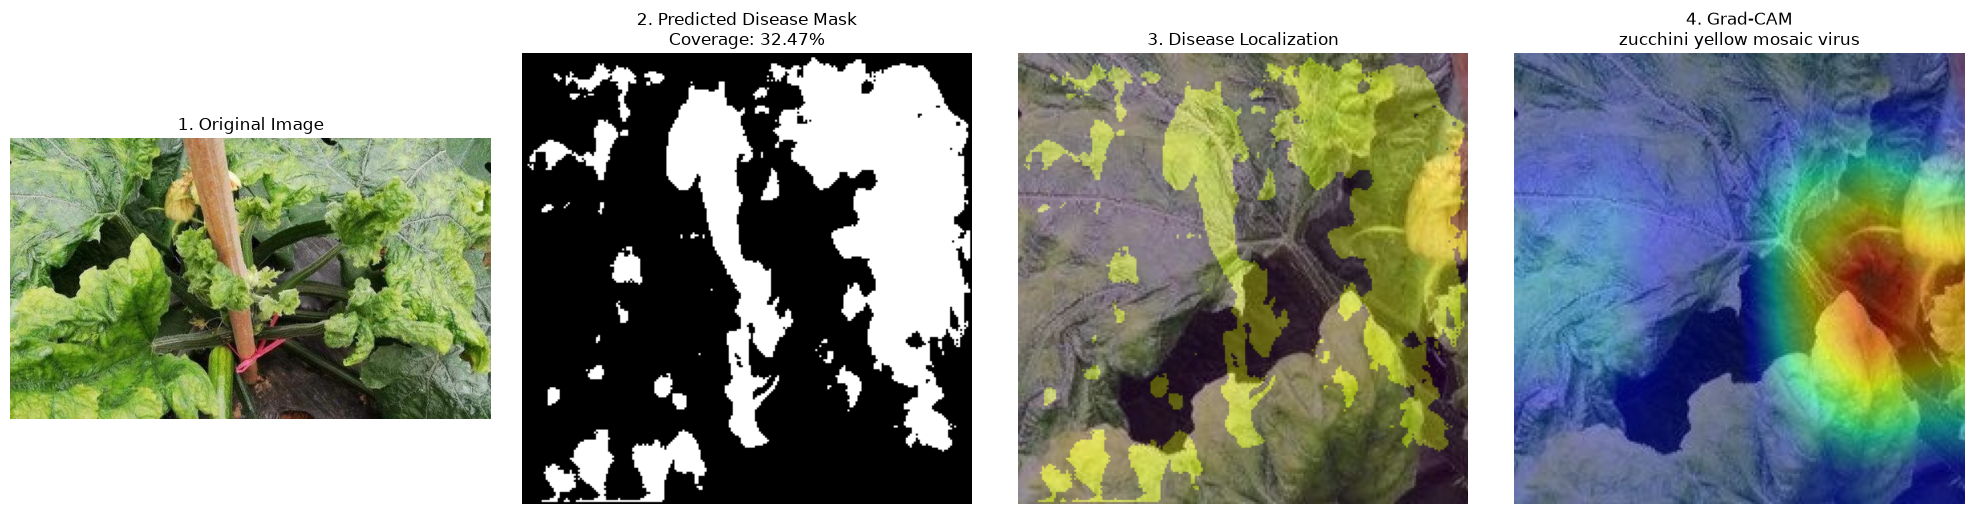


AgriSense Interpretation Guide

Predicted disease : zucchini yellow mosaic virus
Confidence        : 23.63%
Predicted coverage: 32.47%
Grad-CAM mean     : 0.232
Grad-CAM ≥ 0.5    : 16.38%

How to read the four panels:

1. ORIGINAL IMAGE
   → Look at the actual plant, leaves and visible symptoms.

2. PREDICTED DISEASE MASK
   → White = U-Net predicts disease-region pixels.
   → Black = U-Net predicts background/non-disease.

3. DISEASE LOCALIZATION
   → Check whether the predicted mask falls on meaningful
     plant/leaf regions rather than unrelated background.

4. GRAD-CAM
   → Warmer colors = stronger classifier activation.
   → Check whether strong activation is concentrated
     on relevant plant/disease regions.

Important:
   → Mask coverage is NOT a validated disease-severity score.
   → Grad-CAM is an explanation, not a segmentation mask.
   → Grad-CAM and U-Net do not need to match exactly.


In [27]:
visualize_agrisense_result(test_image, result)

In [28]:
# Image Integration Test

test_samples = df_clean[df_clean["Split"] == "Test"].head(5).copy()

integration_results = []

for _, row in test_samples.iterrows():

    image = Image.open(row["actual_image_path"]).convert("RGB")

    result = run_agrisense_prediction(image)

    gradcam_high = (result["gradcam_map"] >= 0.5).mean()

    integration_results.append({
        "Image": row["Name"],
        "True Disease": row["Disease"],
        "Predicted Disease": result["predicted_disease"],
        "Correct": row["Disease"] == result["predicted_disease"],
        "Confidence": result["confidence"],
        "Mask Coverage": result["mask_coverage"],
        "GradCAM Mean": result["gradcam_map"].mean(),
        "GradCAM >= 0.5": gradcam_high
    })

integration_df = pd.DataFrame(integration_results)

integration_df

,Image,True Disease,Predicted Disease,Correct,Confidence,Mask Coverage,GradCAM Mean,GradCAM >= 0.5
0,zucchini_yellow_mosaic_virus_66.jpg,zucchini yellow mosaic virus,zucchini yellow mosaic virus,True,0.236254,0.324697,0.231717,0.163823
1,grape_downy_mildew_275.jpg,grape downy mildew,grape downy mildew,True,0.812208,0.080138,0.408132,0.368822
2,apple_scab_google_0230.jpg,apple scab,tomato early blight,False,0.300246,0.296556,0.286005,0.240454
3,cucumber_bacterial_wilt_google_0020.jpg,cucumber bacterial wilt,cucumber bacterial wilt,True,0.765102,0.065968,0.361834,0.297154
4,corn_smut_google_0012.jpg,corn smut,corn smut,True,0.847325,0.420799,0.236785,0.181760


In [29]:
display_df = integration_df.copy()

display_df["Confidence"] = (
    display_df["Confidence"] * 100
).round(2)

display_df["Mask Coverage"] = (
    display_df["Mask Coverage"] * 100
).round(2)

display_df["GradCAM Mean"] = (
    display_df["GradCAM Mean"]
).round(3)

display_df["GradCAM >= 0.5"] = (
    display_df["GradCAM >= 0.5"] * 100
).round(2)

display_df

,Image,True Disease,Predicted Disease,Correct,Confidence,Mask Coverage,GradCAM Mean,GradCAM >= 0.5
0,zucchini_yellow_mosaic_virus_66.jpg,zucchini yellow mosaic virus,zucchini yellow mosaic virus,True,23.63,32.47,0.232,16.38
1,grape_downy_mildew_275.jpg,grape downy mildew,grape downy mildew,True,81.22,8.01,0.408,36.88
2,apple_scab_google_0230.jpg,apple scab,tomato early blight,False,30.02,29.66,0.286,24.05
3,cucumber_bacterial_wilt_google_0020.jpg,cucumber bacterial wilt,cucumber bacterial wilt,True,76.51,6.60,0.362,29.72
4,corn_smut_google_0012.jpg,corn smut,corn smut,True,84.73,42.08,0.237,18.18


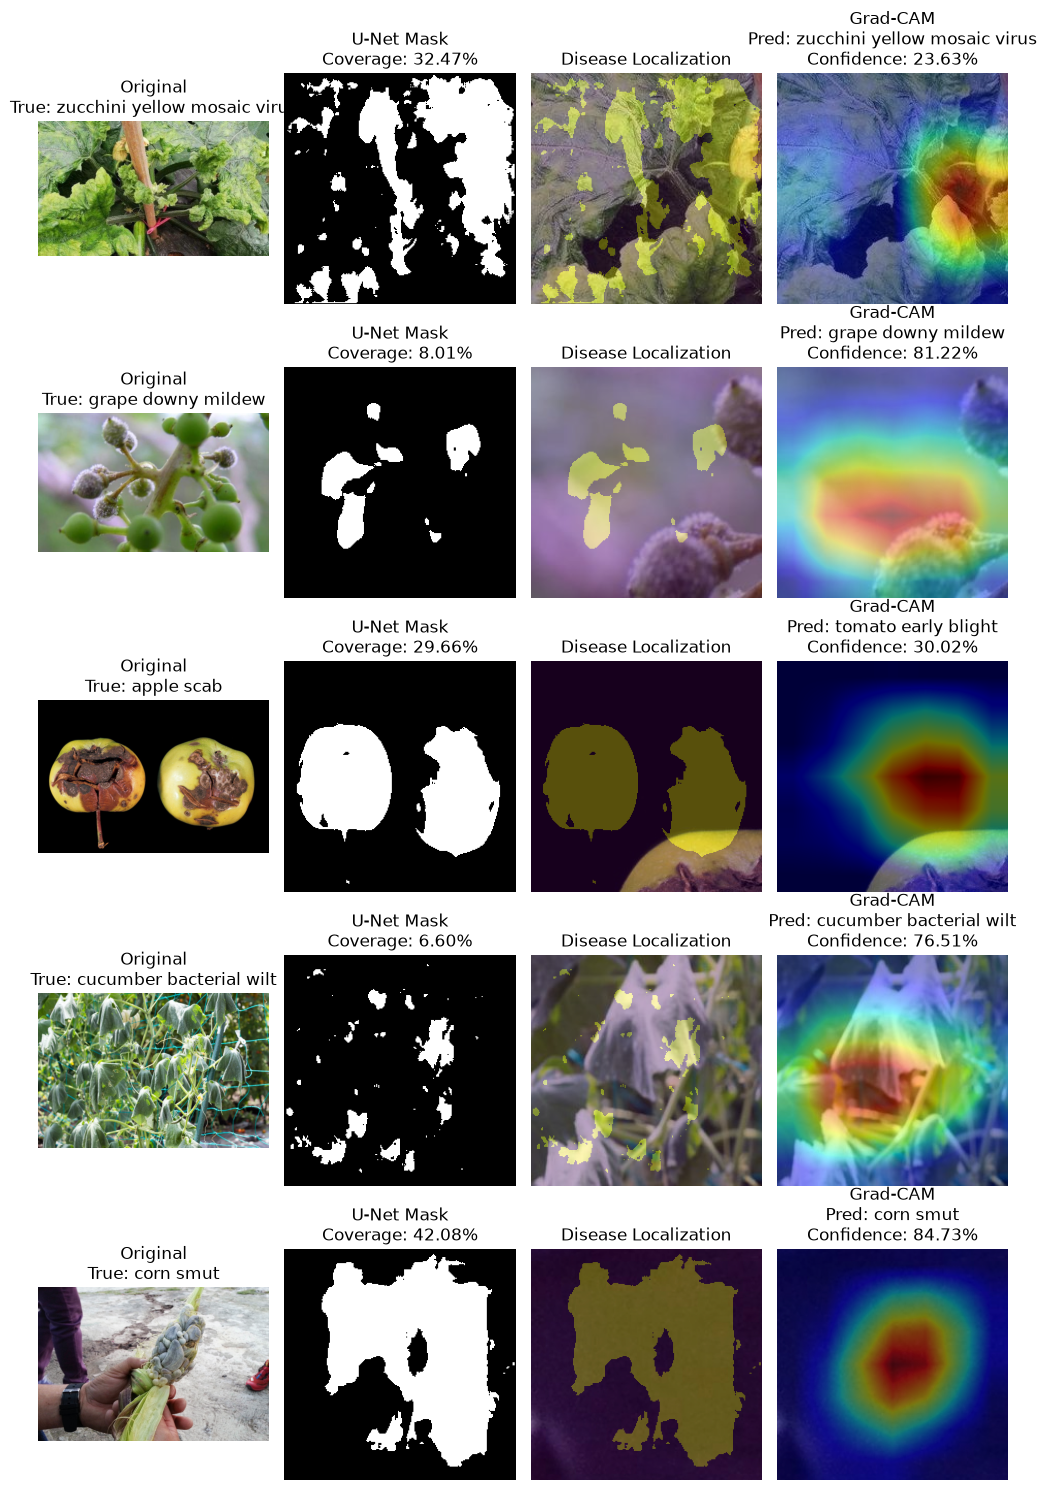

In [30]:
# % image visual inspection

fig, axes = plt.subplots(
    len(test_samples),
    4,
    figsize=(10, 3 * len(test_samples))
)

for i, (_, row) in enumerate(test_samples.iterrows()):

    image = Image.open(row["actual_image_path"]).convert("RGB")

    result = run_agrisense_prediction(image)

    predicted_disease = result["predicted_disease"]
    confidence = result["confidence"]
    predicted_mask = result["predicted_mask"]
    mask_coverage = result["mask_coverage"]
    gradcam_map = result["gradcam_map"]

    correct = row["Disease"] == predicted_disease

    # Original
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(
        f"Original\nTrue: {row['Disease']}"
    )
    axes[i, 0].axis("off")

    # Binary segmentation mask
    axes[i, 1].imshow(predicted_mask, cmap="gray")
    axes[i, 1].set_title(
        f"U-Net Mask\n"
        f"Coverage: {mask_coverage * 100:.2f}%"
    )
    axes[i, 1].axis("off")

    # Segmentation overlay
    axes[i, 2].imshow(image)
    axes[i, 2].imshow(predicted_mask, alpha=0.35)
    axes[i, 2].set_title(
        "Disease Localization"
    )
    axes[i, 2].axis("off")

    # Grad-CAM
    axes[i, 3].imshow(image)
    axes[i, 3].imshow(
        gradcam_map,
        cmap="jet",
        alpha=0.45
    )
    axes[i, 3].set_title(
        f"Grad-CAM\n"
        f"Pred: {predicted_disease}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

In [31]:
# GradCam vs Ground Truth

def analyze_gradcam_mask_overlap(image, mask_path, gradcam_map):
    #Load ground-truth mask
    mask = Image.open(mask_path).convert("L")

    #Apply the SAME aspect-ratio-preserving preprocessing
    mask = resize_mask_with_padding(mask, (224, 224))

    ground_truth_mask = np.array(mask) > 0

    #Strong Grad-CAM region
    gradcam_region = gradcam_map >= 0.5

    #Overlap
    overlap = gradcam_region & ground_truth_mask

    gradcam_pixels = gradcam_region.sum()
    disease_pixels = ground_truth_mask.sum()
    overlap_pixels = overlap.sum()

    #Avoid division by zero
    if gradcam_pixels > 0:
        gradcam_inside_disease = overlap_pixels / gradcam_pixels
    else:
        gradcam_inside_disease = 0

    if disease_pixels > 0:
        disease_covered_by_gradcam = overlap_pixels / disease_pixels
    else:
        disease_covered_by_gradcam = 0

    return (
        gradcam_inside_disease,
        disease_covered_by_gradcam
    )

In [32]:
def resize_mask_with_padding(mask, size=(224, 224)):
    target_h, target_w = size

    w, h = mask.size

    scale = min(
        target_w / w,
        target_h / h
    )

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    # Preserve mask labels
    mask = mask.resize(
        (new_w, new_h),
        Image.Resampling.NEAREST
    )

    # Black background
    canvas = Image.new(
        "L",
        (target_w, target_h),
        0
    )

    left = (target_w - new_w) // 2
    top = (target_h - new_h) // 2

    canvas.paste(
        mask,
        (left, top)
    )

    return canvas

In [33]:
overlap_results = []

for _, row in test_samples.iterrows():

    image = Image.open(row["actual_image_path"]).convert("RGB")

    result = run_agrisense_prediction(image)

    # Find ground-truth mask
    mask_filename = row["Label file"]

    mask_path = (
        project_root
        / "data"
        / "raw"
        / "PlantSeg"
        / "annotations"
    )

    mask_matches = list(mask_path.rglob(mask_filename))

    if len(mask_matches) != 1:
        print(f"Mask problem: {mask_filename}")
        continue

    gradcam_inside, disease_covered = analyze_gradcam_mask_overlap(
        image,
        mask_matches[0],
        result["gradcam_map"]
    )

    overlap_results.append({
        "Image": row["Name"],
        "True Disease": row["Disease"],
        "Predicted Disease": result["predicted_disease"],
        "Correct": row["Disease"] == result["predicted_disease"],
        "GradCAM inside disease %": gradcam_inside * 100,
        "Disease covered by GradCAM %": disease_covered * 100
    })

overlap_df = pd.DataFrame(overlap_results)

overlap_df.round(2)

,Image,True Disease,Predicted Disease,Correct,GradCAM inside disease %,Disease covered by GradCAM %
0,zucchini_yellow_mosaic_virus_66.jpg,zucchini yellow mosaic virus,zucchini yellow mosaic virus,True,81.17,32.97
1,grape_downy_mildew_275.jpg,grape downy mildew,grape downy mildew,True,17.26,67.59
2,apple_scab_google_0230.jpg,apple scab,tomato early blight,False,24.65,44.87
3,cucumber_bacterial_wilt_google_0020.jpg,cucumber bacterial wilt,cucumber bacterial wilt,True,99.22,56.62
4,corn_smut_google_0012.jpg,corn smut,corn smut,True,28.11,100.00


In [34]:
print("Grad-CAM / Disease Mask Analysis")
print("=" * 50)

print(
    "Mean Grad-CAM inside disease:",
    round(overlap_df["GradCAM inside disease %"].mean(), 2),
    "%"
)

print(
    "Mean disease coverage by Grad-CAM:",
    round(overlap_df["Disease covered by GradCAM %"].mean(), 2),
    "%"
)

print(
    "Correct predictions:",
    overlap_df["Correct"].sum(),
    "/",
    len(overlap_df)
)

Grad-CAM / Disease Mask Analysis
Mean Grad-CAM inside disease: 50.08 %
Mean disease coverage by Grad-CAM: 60.41 %
Correct predictions: 4 / 5


In [35]:
print("Grad-CAM / Disease Mask Analysis")
print("=" * 50)

print(
    "Mean Grad-CAM inside disease:",
    round(overlap_df["GradCAM inside disease %"].mean(), 2),
    "%"
)

print(
    "Mean disease coverage by Grad-CAM:",
    round(overlap_df["Disease covered by GradCAM %"].mean(), 2),
    "%"
)

print(
    "Correct predictions:",
    overlap_df["Correct"].sum(),
    "/",
    len(overlap_df)
)

Grad-CAM / Disease Mask Analysis
Mean Grad-CAM inside disease: 50.08 %
Mean disease coverage by Grad-CAM: 60.41 %
Correct predictions: 4 / 5


## Model Integration Conclusion

The trained AgriSense models were successfully integrated into a single inference pipeline.

The selected fine-tuned ResNet-18 classifier predicts one of 115 plant disease classes and provides a prediction confidence. The U-Net segmentation model identifies the predicted disease-region pixels and calculates predicted mask coverage using the validation-selected threshold of 0.4.

Grad-CAM was integrated using the final convolutional block of the ResNet-18 to provide a visual explanation of the classifier prediction.

The integrated pipeline was tested on multiple held-out test images. The classifier, segmentation model, and Grad-CAM components produced valid outputs and worked together without requiring additional model training.

### Integrated Output

For an input image, AgriSense produces:

1. Predicted disease
2. Classification confidence
3. Predicted disease-region mask
4. Predicted mask coverage
5. Grad-CAM explanation

### Explainability Analysis

Grad-CAM was compared with the ground-truth disease masks on a small set of test images.

The analysis showed that Grad-CAM activation was not consistently restricted to the annotated disease regions. Some examples showed strong alignment with disease areas, while others showed substantial activation outside the annotated regions.

These results suggest that contextual or non-disease visual features may contribute to some classifier predictions. However, the analysis does not establish that the model specifically learned background features.

The Grad-CAM overlap analysis is treated as an exploratory explainability analysis rather than a formal model-performance metric.

### Important Limitations

- The integrated examples are qualitative sanity checks and are not a replacement for the full test-set evaluation performed in the earlier model experiments.
- Predicted mask coverage represents the proportion of pixels classified by U-Net as disease-region pixels; it is not a validated disease-severity score.
- Grad-CAM provides a coarse explanation of classifier activation and should not be interpreted as a pixel-level disease segmentation.
- The current models were trained and evaluated using the cleaned PlantSeg dataset and its established splits.
- External environmental data, agricultural recommendations, and other contextual information have not yet been integrated.

### Selected Models

**Disease Classification:** Fine-tuned ResNet-18

**Disease Localization:** Lightweight U-Net

**Explainability:** Grad-CAM

These trained checkpoints will be reused in the application layer without retraining.